In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CLEANED data (not raw) — this is the whole point of Phase 3
ratings = pd.read_csv('../data/processed/ratings_clean.csv')

print("Ratings loaded:", ratings.shape)

Ratings loaded: (20000263, 4)


In [2]:
# Central tendency statistics
mean_rating = ratings['rating'].mean()
median_rating = ratings['rating'].median()
mode_rating = ratings['rating'].mode()[0]

print(f"Mean rating:   {mean_rating:.3f}")
print(f"Median rating: {median_rating:.3f}")
print(f"Mode rating:   {mode_rating}")

# Frequency table — how many ratings exist at each value
rating_counts = ratings['rating'].value_counts().sort_index()
rating_percent = (rating_counts / len(ratings) * 100).round(2)

freq_table = pd.DataFrame({'count': rating_counts, 'percent': rating_percent})
print("\nRating Frequency Table:")
print(freq_table)

Mean rating:   3.526
Median rating: 3.500
Mode rating:   4.0

Rating Frequency Table:
          count  percent
rating                  
0.5      239125     1.20
1.0      680732     3.40
1.5      279252     1.40
2.0     1430997     7.15
2.5      883398     4.42
3.0     4291193    21.46
3.5     2200156    11.00
4.0     5561926    27.81
4.5     1534824     7.67
5.0     2898660    14.49


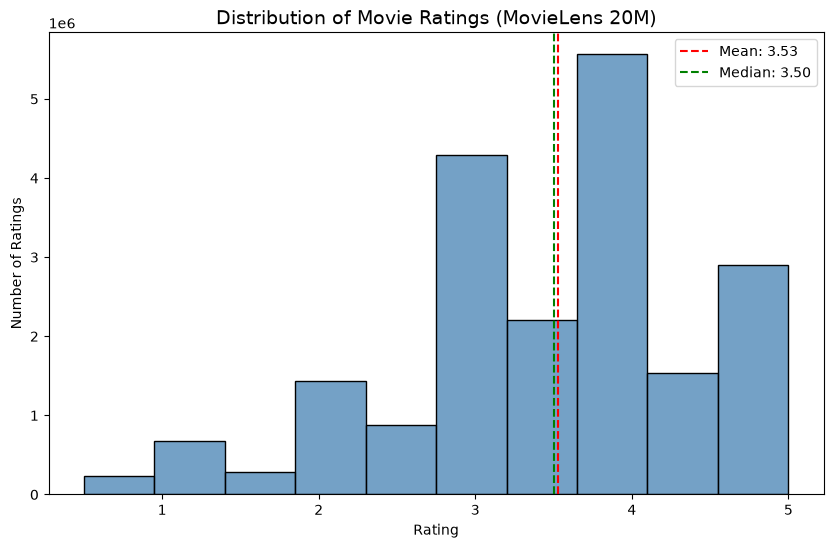

In [3]:
plt.figure(figsize=(10, 6))
sns.histplot(ratings['rating'], bins=10, kde=False, color='steelblue')
plt.title('Distribution of Movie Ratings (MovieLens 20M)', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating, color='green', linestyle='--', label=f'Median: {median_rating:.2f}')
plt.legend()
plt.show()

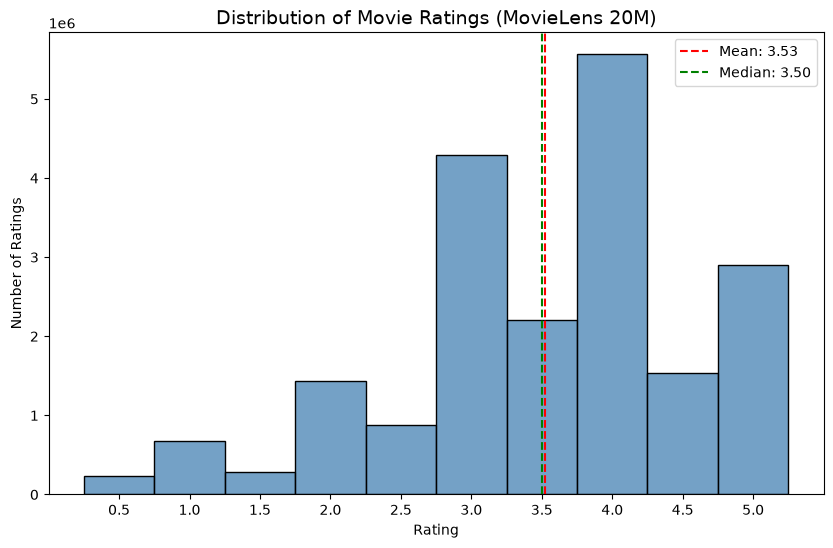

In [4]:
plt.figure(figsize=(10, 6))

# Define bin edges so each bar is centered exactly on a real rating value
bin_edges = [x - 0.25 for x in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5]]

sns.histplot(ratings['rating'], bins=bin_edges, kde=False, color='steelblue')
plt.title('Distribution of Movie Ratings (MovieLens 20M)', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
plt.axvline(median_rating, color='green', linestyle='--', label=f'Median: {median_rating:.2f}')
plt.legend()
plt.show()

In [5]:
# Load the cleaned movies data too
movies = pd.read_csv('../data/processed/movies_clean.csv')

# Merge ratings with movie titles
ratings_movies = ratings.merge(movies, on='movieId', how='left')

print("Merged shape:", ratings_movies.shape)
print(ratings_movies[['userId', 'movieId', 'rating', 'title']].head())

Merged shape: (20000263, 6)
   userId  movieId  rating                                              title
0       1        2     3.5                                     Jumanji (1995)
1       1       29     3.5  City of Lost Children, The (Cité des enfants p...
2       1       32     3.5          Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
3       1       47     3.5                        Seven (a.k.a. Se7en) (1995)
4       1       50     3.5                         Usual Suspects, The (1995)


In [6]:
# Count how many ratings each movie received
rating_counts = ratings_movies.groupby('title')['rating'].count().sort_values(ascending=False)

# Top 20 most-rated movies
top_20_most_rated = rating_counts.head(20)
print(top_20_most_rated)

title
Pulp Fiction (1994)                                      67310
Forrest Gump (1994)                                      66172
Shawshank Redemption, The (1994)                         63366
Silence of the Lambs, The (1991)                         63299
Jurassic Park (1993)                                     59715
Star Wars: Episode IV - A New Hope (1977)                54502
Braveheart (1995)                                        53769
Terminator 2: Judgment Day (1991)                        52244
Matrix, The (1999)                                       51334
Schindler's List (1993)                                  50054
Toy Story (1995)                                         49695
Fugitive, The (1993)                                     49581
Apollo 13 (1995)                                         47777
Independence Day (a.k.a. ID4) (1996)                     47048
Usual Suspects, The (1995)                               47006
Star Wars: Episode VI - Return of the Jedi (1983)

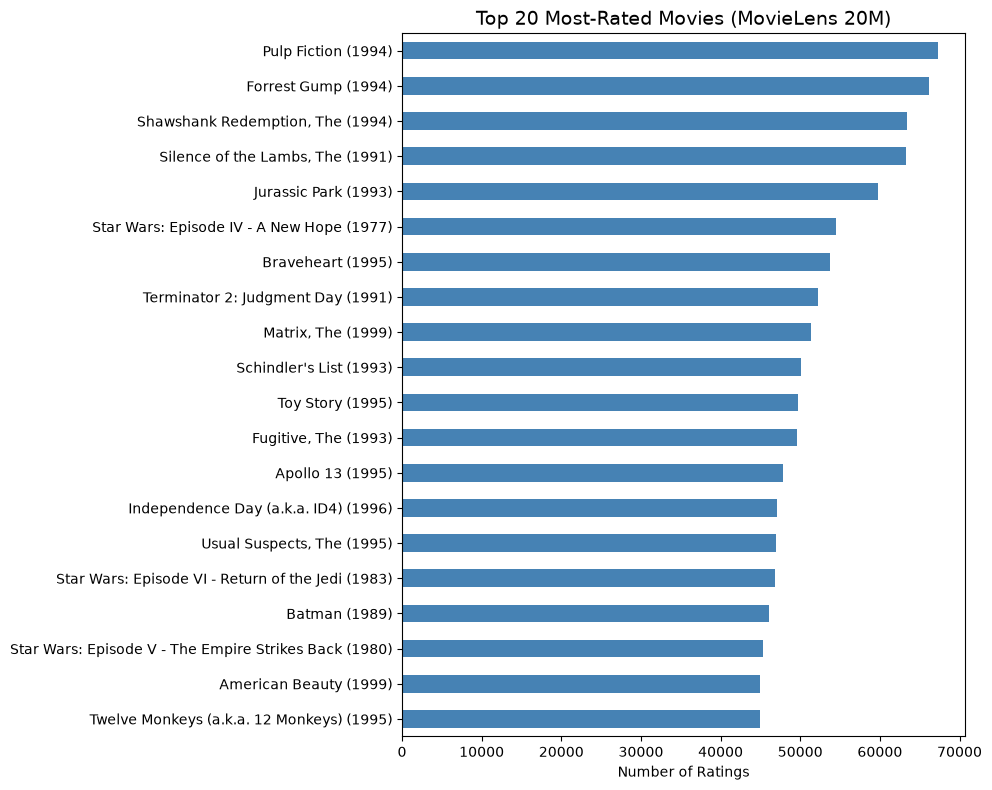

In [7]:
plt.figure(figsize=(10, 8))
top_20_most_rated.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Most-Rated Movies (MovieLens 20M)', fontsize=14)
plt.xlabel('Number of Ratings')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [8]:
top_20_total = top_20_most_rated.sum()
overall_total = len(ratings_movies)
print(f"Top 20 movies account for {top_20_total:,} ratings")
print(f"That's {(top_20_total / overall_total) * 100:.2f}% of all 20 million ratings")
print(f"...from just {20} out of {movies['movieId'].nunique():,} movies ({20 / movies['movieId'].nunique() * 100:.3f}% of the catalog)")

Top 20 movies account for 1,051,045 ratings
That's 5.26% of all 20 million ratings
...from just 20 out of 27,278 movies (0.073% of the catalog)


In [9]:
# Calculate average rating AND rating count per movie
movie_stats = ratings_movies.groupby('title')['rating'].agg(['mean', 'count'])
movie_stats.columns = ['avg_rating', 'rating_count']

# Naive "highest rated" - sorted by average only, no threshold
naive_top_20 = movie_stats.sort_values('avg_rating', ascending=False).head(20)
print(naive_top_20)

                                                    avg_rating  rating_count
title                                                                       
Tales That Witness Madness (1973)                          5.0             1
Stargate SG-1 Children of the Gods - Final Cut ...         5.0             1
Stealing a Nation (2004)                                   5.0             1
Abendland (2011)                                           5.0             1
Latin Music USA (2009)                                     5.0             1
Pursuit of Unhappiness, The (Anleitung zum Ungl...         5.0             1
Parasites, Les (1999)                                      5.0             1
This Thing With Sarah (2013)                               5.0             1
Inquire Within (2012)                                      5.0             1
Island at War (2004)                                       5.0             1
Iran Is Not the Problem (2008)                             5.0             1

In [10]:
# Apply minimum threshold of 500 ratings
qualified_movies = movie_stats[movie_stats['rating_count'] >= 500]

print(f"Movies before threshold: {len(movie_stats):,}")
print(f"Movies after threshold (500+ ratings): {len(qualified_movies):,}")

# Now find the genuinely highest-rated movies among qualified ones
top_20_highest_rated = qualified_movies.sort_values('avg_rating', ascending=False).head(20)
print(top_20_highest_rated)

Movies before threshold: 26,729
Movies after threshold (500+ ratings): 4,489
                                                    avg_rating  rating_count
title                                                                       
Shawshank Redemption, The (1994)                      4.446990         63366
Godfather, The (1972)                                 4.364732         41355
Usual Suspects, The (1995)                            4.334372         47006
Schindler's List (1993)                               4.310175         50054
Godfather: Part II, The (1974)                        4.275641         27398
Seven Samurai (Shichinin no samurai) (1954)           4.274180         11611
Rear Window (1954)                                    4.271334         17449
Band of Brothers (2001)                               4.263182          4305
Casablanca (1942)                                     4.258327         24349
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)         4.256935          6525

A movie with 2 ratings of 5.0 has an average of 5.0 — but so would a movie that, if 500 people watched it, might settle at 3.8. Small samples are statistically volatile: each additional rating swings the average wildly. Large samples are statistically stable: one new rating barely moves a 60,000-rating average. This is a direct application of the Law of Large Numbers — a core statistics concept worth naming explicitly in your report, since interviewers love hearing it referenced correctly.

In [11]:
# Quick verification of this gap
unrated_count = movies['movieId'].nunique() - ratings_movies['title'].nunique()
print(f"Movies with zero ratings: {unrated_count}")

Movies with zero ratings: 549


In [12]:
# Ratings per user
user_activity = ratings.groupby('userId')['rating'].count()

print("User Activity Summary Statistics:")
print(user_activity.describe())

print(f"\nMost active user rated: {user_activity.max():,} movies")
print(f"Least active user rated: {user_activity.min():,} movies")
print(f"Median user rated: {user_activity.median():,.0f} movies")

User Activity Summary Statistics:
count    138493.000000
mean        144.413530
std         230.267257
min          20.000000
25%          35.000000
50%          68.000000
75%         155.000000
max        9254.000000
Name: rating, dtype: float64

Most active user rated: 9,254 movies
Least active user rated: 20 movies
Median user rated: 68 movies


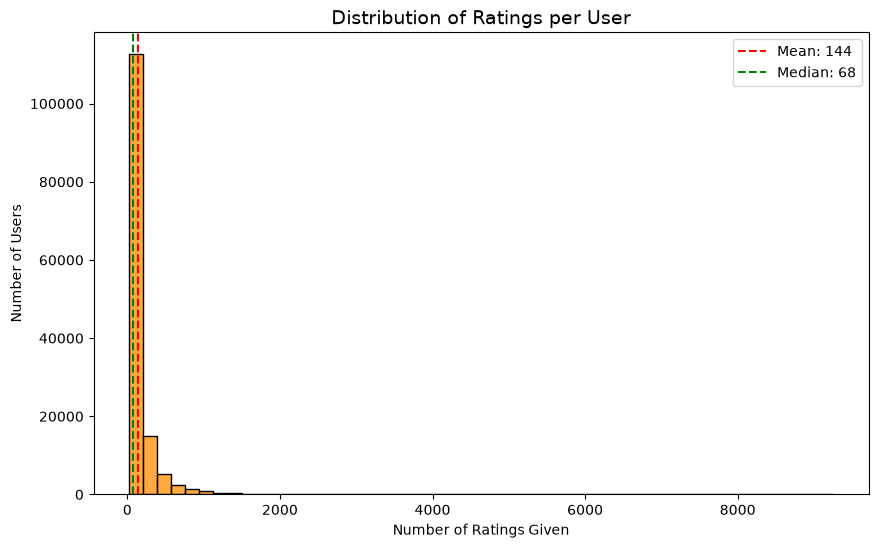

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(user_activity, bins=50, color='darkorange')
plt.title('Distribution of Ratings per User', fontsize=14)
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Users')
plt.axvline(user_activity.mean(), color='red', linestyle='--', label=f'Mean: {user_activity.mean():.0f}')
plt.axvline(user_activity.median(), color='green', linestyle='--', label=f'Median: {user_activity.median():.0f}')
plt.legend()
plt.show()

In [14]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

max_possible_ratings = n_users * n_movies
sparsity = (1 - (n_ratings / max_possible_ratings)) * 100

print(f"Users: {n_users:,}")
print(f"Movies (rated at least once): {n_movies:,}")
print(f"Actual ratings: {n_ratings:,}")
print(f"Max possible ratings: {max_possible_ratings:,}")
print(f"Sparsity: {sparsity:.3f}%")

Users: 138,493
Movies (rated at least once): 26,744
Actual ratings: 20,000,263
Max possible ratings: 3,703,856,792
Sparsity: 99.460%


In [15]:
# Split the pipe-separated genres into individual rows (one genre per row)
movies_genres_split = movies.copy()
movies_genres_split['genres'] = movies_genres_split['genres'].str.split('|')
movies_exploded = movies_genres_split.explode('genres')

# Remove the "(no genres listed)" placeholder for this specific count
genre_frequency = movies_exploded[movies_exploded['genres'] != '(no genres listed)']['genres'].value_counts()

print("Genre Frequency (number of movies tagged with each genre):")
print(genre_frequency)

Genre Frequency (number of movies tagged with each genre):
genres
Drama          13344
Comedy          8374
Thriller        4178
Romance         4127
Action          3520
Crime           2939
Horror          2611
Documentary     2471
Adventure       2329
Sci-Fi          1743
Mystery         1514
Fantasy         1412
War             1194
Children        1139
Musical         1036
Animation       1027
Western          676
Film-Noir        330
IMAX             196
Name: count, dtype: int64


In [16]:
# Merge exploded genres with ratings to analyze at the rating level
ratings_genres = ratings_movies.copy()
ratings_genres['genres'] = ratings_genres['genres'].str.split('|')
ratings_genres_exploded = ratings_genres.explode('genres')

# Remove "(no genres listed)" rows for this analysis
ratings_genres_exploded = ratings_genres_exploded[ratings_genres_exploded['genres'] != '(no genres listed)']

# Calculate rating count and average rating per genre
genre_stats = ratings_genres_exploded.groupby('genres')['rating'].agg(['count', 'mean'])
genre_stats.columns = ['rating_count', 'avg_rating']
genre_stats = genre_stats.sort_values('rating_count', ascending=False)

print(genre_stats)

             rating_count  avg_rating
genres                               
Drama             8857853    3.674296
Comedy            7502234    3.426011
Action            5614208    3.443864
Thriller          5313506    3.507111
Adventure         4380351    3.501893
Romance           3802002    3.541803
Crime             3298335    3.674528
Sci-Fi            3150141    3.436773
Fantasy           2111403    3.505945
Children          1669249    3.408114
Mystery           1557282    3.663509
Horror            1482737    3.277224
Animation         1140476    3.617494
War               1048618    3.809531
Musical            870915    3.558091
IMAX               492366    3.655946
Western            423714    3.570498
Documentary        244619    3.739718
Film-Noir          216689    3.965381


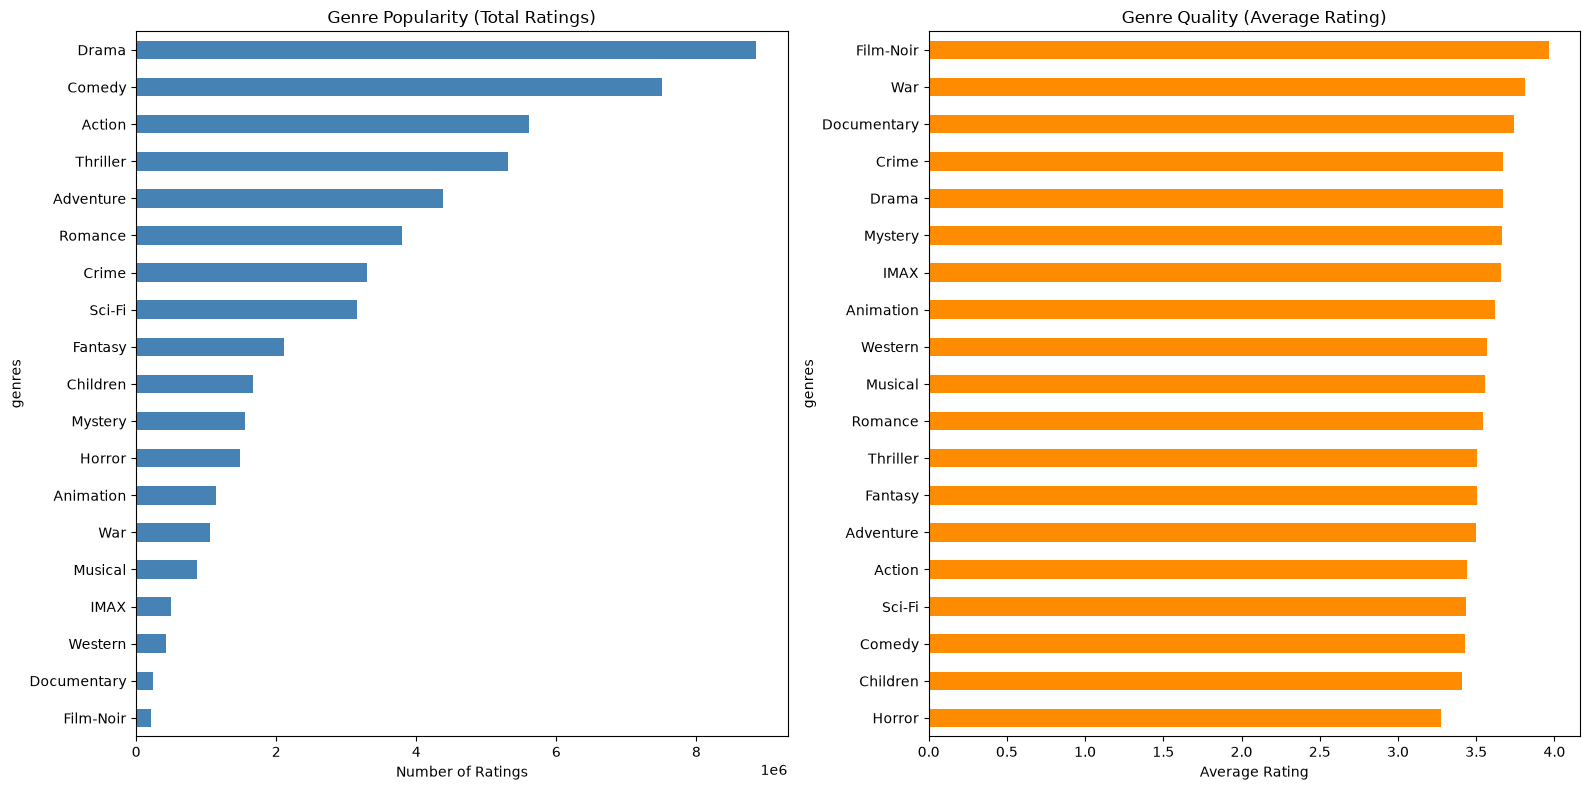

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: genre popularity (rating count)
genre_stats.sort_values('rating_count').plot(
    kind='barh', y='rating_count', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Genre Popularity (Total Ratings)')
axes[0].set_xlabel('Number of Ratings')

# Right: genre quality (average rating)
genre_stats.sort_values('avg_rating').plot(
    kind='barh', y='avg_rating', ax=axes[1], color='darkorange', legend=False
)
axes[1].set_title('Genre Quality (Average Rating)')
axes[1].set_xlabel('Average Rating')

plt.tight_layout()
plt.show()

In [19]:
# Re-convert timestamp to datetime (CSV files don't preserve dtype info)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'])

# Verify it worked
print(ratings['timestamp'].dtype)

datetime64[us]


In [20]:
# Extract year from the timestamp
ratings['rating_year'] = ratings['timestamp'].dt.year

ratings_per_year = ratings.groupby('rating_year').size()
print(ratings_per_year)

rating_year
1995          4
1996    1612609
1997     700982
1998     308070
1999    1198384
2000    1953659
2001    1186125
2002     869719
2003    1035878
2004    1170049
2005    1803158
2006    1171836
2007    1053430
2008    1158777
2009     930036
2010     903691
2011     766366
2012     731389
2013     599327
2014     562888
2015     283886
dtype: int64


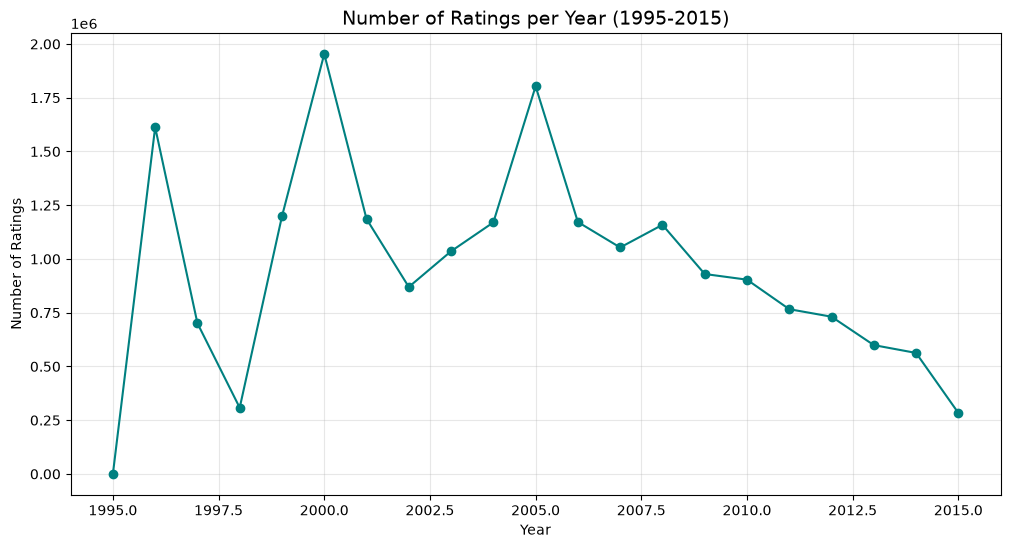

In [21]:
plt.figure(figsize=(12, 6))
ratings_per_year.plot(kind='line', marker='o', color='teal')
plt.title('Number of Ratings per Year (1995-2015)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Ratings')
plt.grid(alpha=0.3)
plt.show()

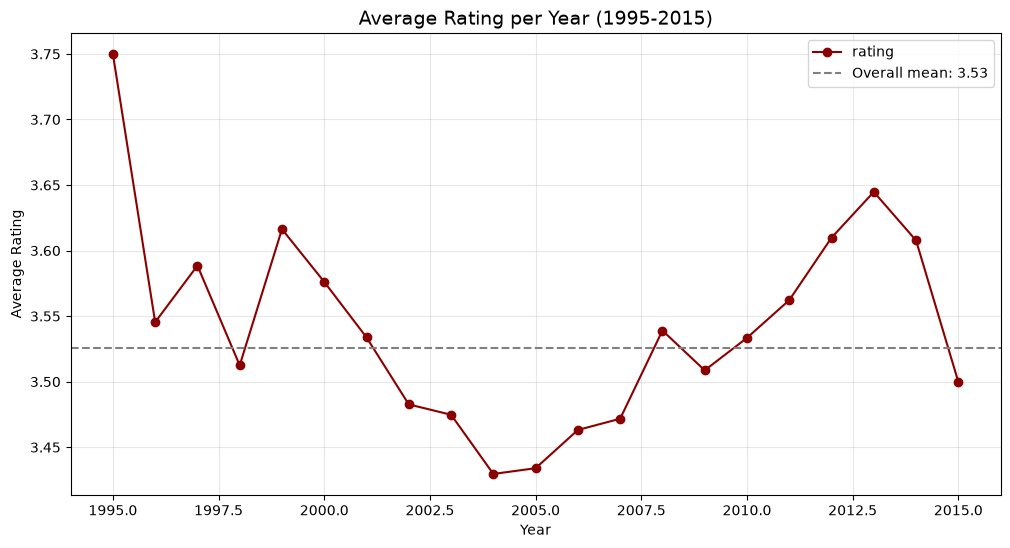

In [22]:
avg_rating_per_year = ratings.groupby('rating_year')['rating'].mean()

plt.figure(figsize=(12, 6))
avg_rating_per_year.plot(kind='line', marker='o', color='darkred')
plt.title('Average Rating per Year (1995-2015)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.axhline(ratings['rating'].mean(), color='gray', linestyle='--', label=f"Overall mean: {ratings['rating'].mean():.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

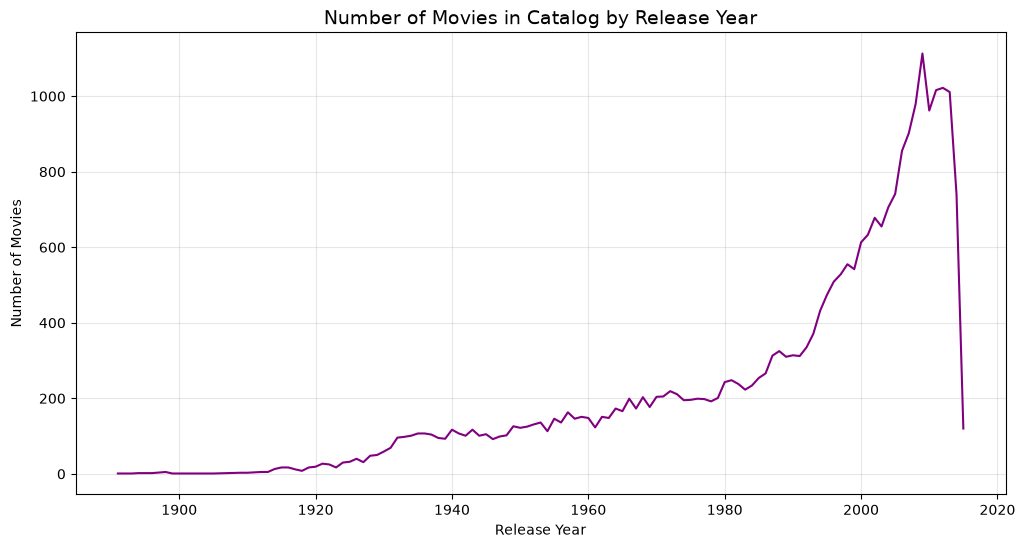

In [23]:
# Extract release year from the movie title (it's embedded in parentheses)
movies['release_year'] = movies['title'].str.extract(r'\((\d{4})\)')
movies['release_year'] = pd.to_numeric(movies['release_year'], errors='coerce')

movies_per_year = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
movies_per_year.plot(kind='line', color='purple')
plt.title('Number of Movies in Catalog by Release Year', fontsize=14)
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(alpha=0.3)
plt.show()